Q1.What is Boosting in Machine Learning? Explain how it improves weak learners.

Ans:-

Boosting is an ensemble learning technique that combines multiple weak learners (models with low accuracy) to form a strong predictive model.

How it works:

* Models are trained sequentially, not independently.

* Each new model focuses on the errors made by the previous model.

* Misclassified data points are given higher importance (weights).

* Improvement of weak learners:

* Converts weak learners into a strong learner by:

* Reducing bias

* Reducing variance

* Improving accuracy step-by-step

Example:

If one model misclassifies some points, the next model tries harder to correct those mistakes.
___
Q2.Difference between AdaBoost and Gradient Boosting

Ans:-

AdaBoost:

* Works by assigning weights to data points

* Misclassified points get higher weight

 * Uses simple models like decision stumps

* Focus is on re-weighting data

Gradient Boosting:

* Works by minimizing loss function using gradients

* Each model corrects residual errors

* More flexible and powerful

* Focus is on error optimization
___
Q3.How does regularization help in XGBoost?

Ans:-

Regularization in XGBoost helps in preventing overfitting.

Key benefits:

* Controls model complexity

* Penalizes large weights

* Improves generalization

Types:

1. L1 Regularization (Lasso)

2. L2 Regularization (Ridge)


___
Q4.Why is CatBoost efficient for categorical data?

Ans:-

CatBoost is specially designed to handle categorical features efficiently.

**Reasons:**

* Automatically converts categorical variables

* Uses ordered encoding to avoid data leakage

* No need for manual preprocessing like one-hot encoding

**Advantages:**

* Faster training

*  Better accuracy

 * Reduced preprocessing effort
 ---
 Q5.What are some real-world applications where boosting techniques are preferred over bagging methods?

Ans:-

Boosting techniques are preferred in real-world applications where high prediction accuracy and handling complex patterns are important.

**Applications:**

**1 .Fraud Detection:**

* Used in banking to detect fraudulent transactions

* Boosting focuses on rare and misclassified fraud cases

* Credit Scoring / Loan Prediction:

* Predicts whether a customer will repay a loan

* Helps identify high-risk customers more accurately

**2. Medical Diagnosis:**

* Detects diseases like cancer

* Improves detection of critical and hard-to-classify cases

**Customer Churn Prediction:**

* Identifies customers likely to leave a service

* Helps companies take preventive actions

**3. Recommendation Systems:**

* Used in platforms like e-commerce and streaming

* Improves personalized suggestions
----
Q6.: Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy

Ans:-

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = AdaBoostClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


Q7. Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score

Ans:-

In [4]:

 from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7756446042829698


Q8.Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy

Ans:-

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model (clean version - no warning)
model = XGBClassifier(eval_metric='logloss')

# Hyperparameter tuning
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(model, param_grid, cv=3)

# Train
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Output
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy)

Best Parameters: {'learning_rate': 0.1}
Accuracy: 0.956140350877193


Q9. Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn

In [11]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


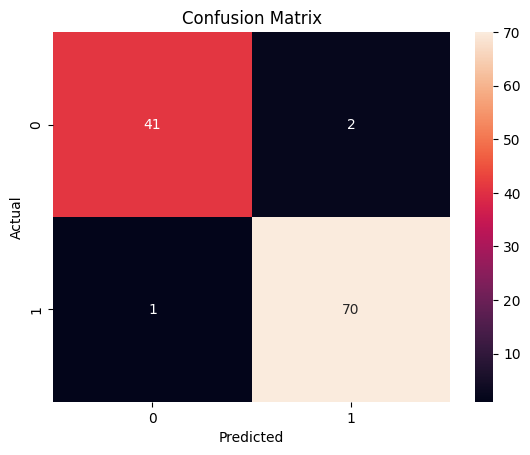

In [12]:
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CatBoost model
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Q10. You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
● Data preprocessing & handling missing/categorical values
● Choice between AdaBoost, XGBoost, or CatBoost
● Hyperparameter tuning strategy
● Evaluation metrics you'd choose and why
● How the business would benefit from your model

Ans:-

1. Data Preprocessing

Handle missing values:

* Numerical → mean/median

* Categorical → mode

Encode categorical variables:

* Use CatBoost (no encoding needed) OR label encoding

Handle imbalance:

* SMOTE or class weighting

2. Model Choice

AdaBoost:

* Simple but less powerful

XGBoost:

* Good for structured data

* Handles missing values well

CatBoost (Best Choice):

* Handles categorical data automatically

* Reduces preprocessing effort

3. Hyperparameter Tuning

* Use GridSearchCV / RandomizedSearchCV

Tune:

* learning_rate

* n_estimators

* max_depth

4. Evaluation Metrics

* Accuracy (not enough for imbalance)

* Precision → reduces false positives

* Recall → reduces false negatives (important in loans)

* F1-score → balance

* ROC-AUC → overall performance

5. Business Benefits

* Better risk prediction

* Reduced loan defaults

* Improved profit

* Better customer segmentation
 ----
 ---
 **End**